In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             roc_auc_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../src/models/saved")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_val   = pd.read_csv(PROCESSED_DIR / "X_val.csv")
X_test  = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_test  = pd.read_csv(PROCESSED_DIR / "y_test_evil.csv")['evil'].values

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Evil events in test: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print("Data loaded ✅")

X_train : (763144, 10)
X_test  : (188967, 10)
Evil events in test: 158,432 (83.84%)
Data loaded ✅


In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for inference later
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
print("Features scaled ✅")
print(f"Mean of X_train_scaled (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Std of X_train_scaled (should be ~1) : {X_train_scaled.std():.4f}")

Features scaled ✅
Mean of X_train_scaled (should be ~0): 0.0000
Std of X_train_scaled (should be ~1) : 0.9487


In [3]:
# contamination = expected fraction of anomalies in training
# BETH training has sus events, ~small fraction
contamination_rate = float(pd.read_csv(
    Path("../data/raw/labelled_training_data.csv"), usecols=['sus'])['sus'].mean())

print(f"Contamination rate from training labels: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    max_samples='auto',
    random_state=42,
    n_jobs=-1         # use all CPU cores
)

print("Training Isolation Forest (200 trees)...")
iso_forest.fit(X_train_scaled)
print("Training complete ✅")

joblib.dump(iso_forest, MODELS_DIR / "isolation_forest.pkl")
print("Model saved ✅")

Contamination rate from training labels: 0.0017 (0.17%)
Training Isolation Forest (200 trees)...
Training complete ✅
Model saved ✅


In [4]:
# Raw scores: more negative = more anomalous
raw_scores = iso_forest.decision_function(X_test_scaled)

# Convert to 0-100 risk score (higher = more suspicious)
# Negate and normalize so high score = high risk
risk_scores = -raw_scores
risk_min, risk_max = risk_scores.min(), risk_scores.max()
risk_scores_normalized = ((risk_scores - risk_min) / (risk_max - risk_min)) * 100

print("=== RISK SCORE STATS ===")
print(f"Min  : {risk_scores_normalized.min():.2f}")
print(f"Max  : {risk_scores_normalized.max():.2f}")
print(f"Mean : {risk_scores_normalized.mean():.2f}")

print(f"\nAvg risk score - Evil events  : {risk_scores_normalized[y_test==1].mean():.2f}")
print(f"Avg risk score - Benign events: {risk_scores_normalized[y_test==0].mean():.2f}")

=== RISK SCORE STATS ===
Min  : 0.00
Max  : 100.00
Mean : 82.97

Avg risk score - Evil events  : 89.09
Avg risk score - Benign events: 51.22


=== MODEL EVALUATION ===
PR-AUC  (main metric) : 0.9947
ROC-AUC (reference)   : 0.9896


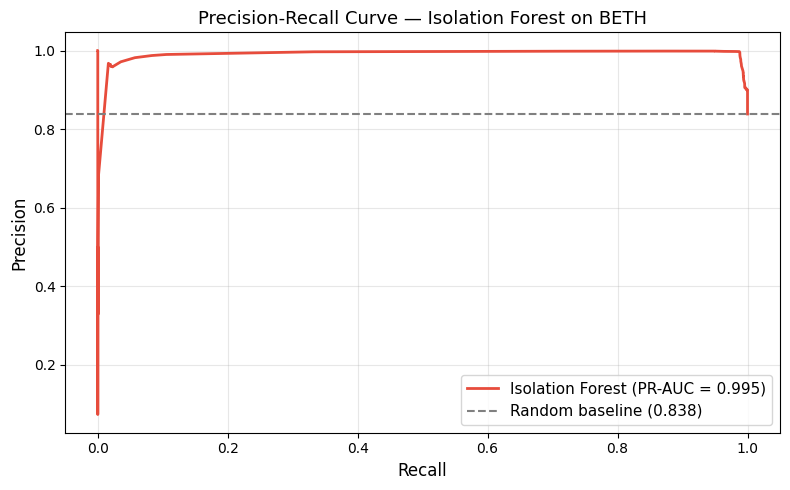

PR curve saved ✅


In [5]:
# PR-AUC — the correct metric for imbalanced security data
pr_auc = average_precision_score(y_test, risk_scores_normalized)
roc_auc = roc_auc_score(y_test, risk_scores_normalized)

print("=== MODEL EVALUATION ===")
print(f"PR-AUC  (main metric) : {pr_auc:.4f}")
print(f"ROC-AUC (reference)   : {roc_auc:.4f}")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, risk_scores_normalized)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='#e74c3c', lw=2,
         label=f'Isolation Forest (PR-AUC = {pr_auc:.3f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'Random baseline ({y_test.mean():.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Isolation Forest on BETH', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "pr_curve_isolation_forest.png", dpi=150)
plt.show()
print("PR curve saved ✅")

In [6]:
# Find threshold that maximizes F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx   = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Best threshold : {best_threshold:.2f}")
print(f"Best F1 score  : {best_f1:.4f}")

y_pred = (risk_scores_normalized >= best_threshold).astype(int)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Evil']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("=== CONFUSION MATRIX ===")
print(f"True  Negatives (Benign correctly allowed) : {cm[0,0]:,}")
print(f"False Positives (Benign wrongly flagged)   : {cm[0,1]:,}")
print(f"False Negatives (Evil missed!)             : {cm[1,0]:,}")
print(f"True  Positives (Evil caught!)             : {cm[1,1]:,}")
print(f"\nRecall (% evil caught) : {cm[1,1]/(cm[1,0]+cm[1,1])*100:.2f}%")

Best threshold : 85.79
Best F1 score  : 0.9924

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.94      0.99      0.96     30535
        Evil       1.00      0.99      0.99    158432

    accuracy                           0.99    188967
   macro avg       0.97      0.99      0.98    188967
weighted avg       0.99      0.99      0.99    188967

=== CONFUSION MATRIX ===
True  Negatives (Benign correctly allowed) : 30,107
False Positives (Benign wrongly flagged)   : 428
False Negatives (Evil missed!)             : 1,953
True  Positives (Evil caught!)             : 156,479

Recall (% evil caught) : 98.77%


In [7]:
# Save scores for SHAP analysis next
np.save(PROCESSED_DIR / "if_risk_scores.npy", risk_scores_normalized)
np.save(PROCESSED_DIR / "scaler_params.npy",
        np.array([risk_min, risk_max]))

with open(PROCESSED_DIR / "model_metadata.json", 'w') as f:
    json.dump({
        'model': 'IsolationForest',
        'n_estimators': 200,
        'contamination': contamination_rate,
        'pr_auc': round(pr_auc, 4),
        'roc_auc': round(roc_auc, 4),
        'best_threshold': round(float(best_threshold), 4),
        'best_f1': round(float(best_f1), 4)
    }, f, indent=2)

print("All outputs saved ✅")
print(json.dumps(json.load(open(PROCESSED_DIR / "model_metadata.json")), indent=2))

All outputs saved ✅
{
  "model": "IsolationForest",
  "n_estimators": 200,
  "contamination": 0.0016628578616879645,
  "pr_auc": 0.9947,
  "roc_auc": 0.9896,
  "best_threshold": 85.7927,
  "best_f1": 0.9924
}
